In [8]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
data = pd.read_csv("Housing.csv")

In [10]:
data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [11]:
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [12]:
data.shape

(545, 13)

In [13]:
data.describe

<bound method NDFrame.describe of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [16]:
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [17]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [18]:
data['furnishingstatus'] = data['furnishingstatus'].map({'furnished':1, 'semi-furnished':0.5, 'unfurnished':0})

In [19]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,1.0
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,1.0
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,0.5
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,1.0
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,1.0


In [20]:
non_numeric_cols = data.select_dtypes(exclude =['number']).columns

In [21]:
print(non_numeric_cols)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea'],
      dtype='object')


In [22]:
for c in non_numeric_cols :
    data[c] = data[c].map({'yes':1,'no':0})

In [23]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0.5
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1.0


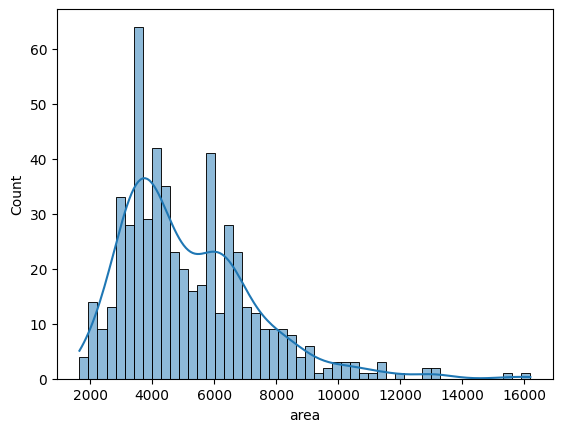

In [24]:
sns.histplot(data["area"],bins = 50,kde = True)
plt.show()

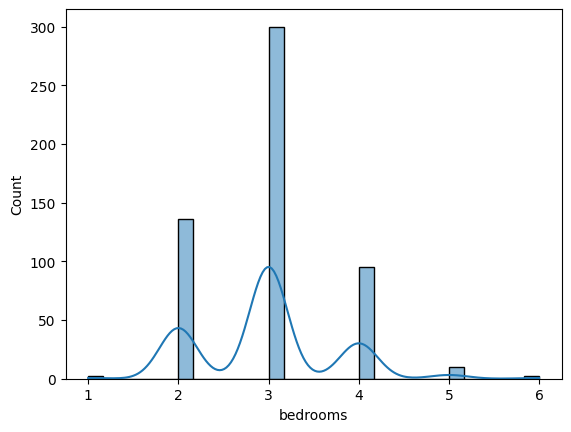

In [25]:
sns.histplot(data["bedrooms"],bins = 30,kde = True)
plt.show()

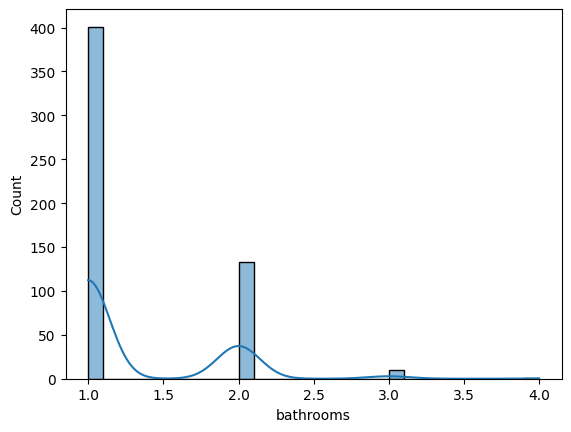

In [26]:
sns.histplot(data["bathrooms"],bins = 30,kde = True)
plt.show()

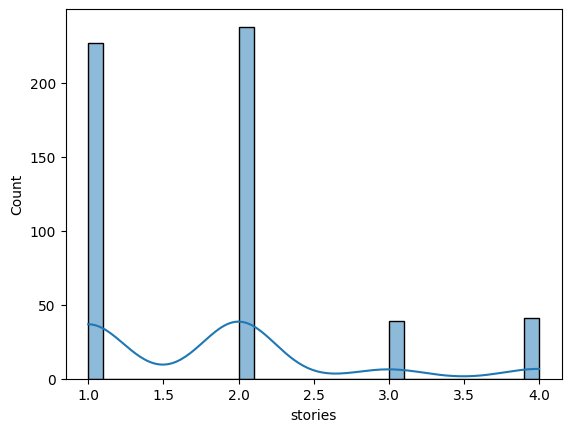

In [27]:
sns.histplot(data["stories"],bins = 30,kde = True)
plt.show()

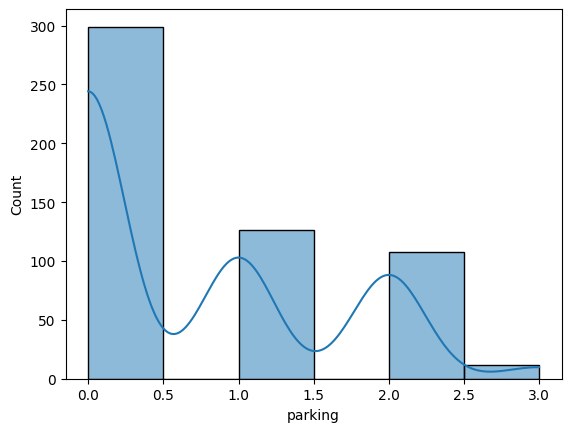

In [29]:
sns.histplot(data["parking"],bins = 6,kde = True)
plt.show()

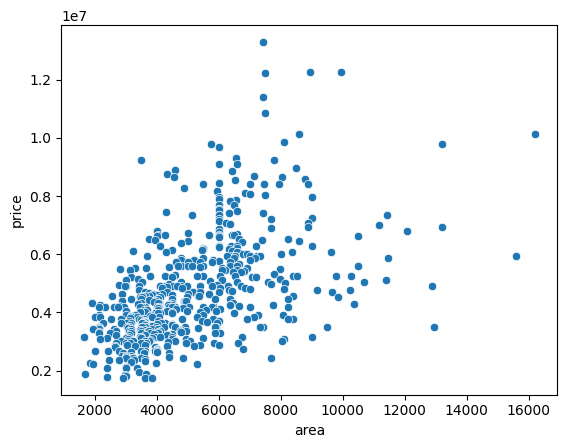

In [32]:
sns.scatterplot(x = 'area',y = 'price',data = data)
plt.show()

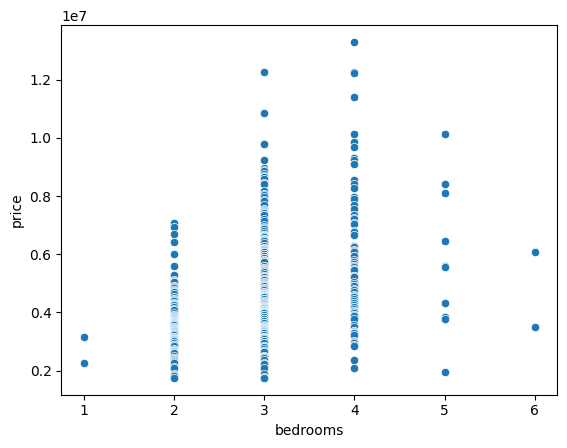

In [33]:
sns.scatterplot(x = 'bedrooms',y = 'price',data = data)
plt.show()

<Axes: >

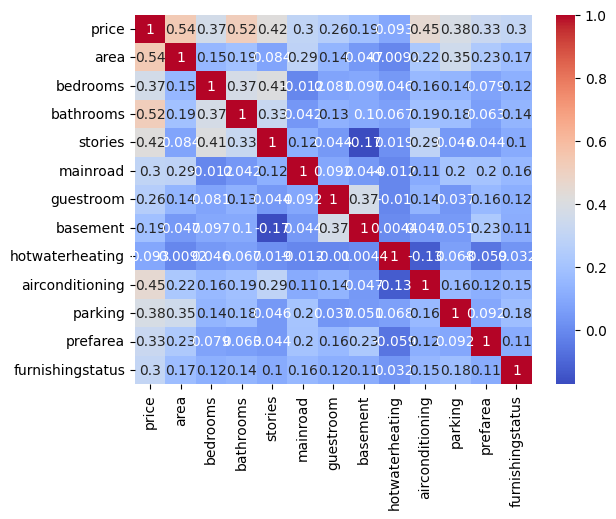

In [34]:
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

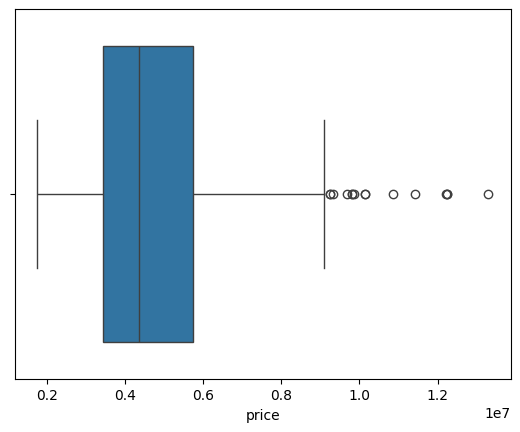

In [36]:
sns.boxplot(x=data['price'])
plt.show()

In [37]:
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1

In [38]:
print(IQR)

2310000.0


In [39]:
outliers = data[(data['price'] < (Q1 - 1.5 * IQR)) |
                (data['price'] > (Q3 + 1.5 * IQR))]

In [40]:
print(outliers)

       price   area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0   13300000   7420         4          2        3         1          0   
1   12250000   8960         4          4        4         1          0   
2   12250000   9960         3          2        2         1          0   
3   12215000   7500         4          2        2         1          0   
4   11410000   7420         4          1        2         1          1   
5   10850000   7500         3          3        1         1          0   
6   10150000   8580         4          3        4         1          0   
7   10150000  16200         5          3        2         1          0   
8    9870000   8100         4          1        2         1          1   
9    9800000   5750         3          2        4         1          1   
10   9800000  13200         3          1        2         1          0   
11   9681000   6000         4          3        2         1          1   
12   9310000   6550         4         

In [41]:
outliers.shape

(15, 13)

In [42]:
data = data.drop(outliers.index)

In [43]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,0.5
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,0.0
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,1.0
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,1.0
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,0.5


In [44]:
data['price'] = np.log(data['price'])
data['area'] = np.log(data['area'])
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,16.023785,8.699515,4,1,2,1,0,1,0,0,2,0,0.5
16,16.023785,8.794825,4,2,2,1,1,1,0,1,1,1,0.0
17,16.008281,9.047821,3,2,4,1,0,0,0,1,2,0,1.0
18,16.000438,8.433812,3,2,2,1,1,0,0,1,2,0,1.0
19,15.996493,8.767173,3,2,2,1,0,0,0,1,1,1,0.5


In [45]:
print(np.exp(8.767173))

6419.997453289179


In [49]:
data.to_csv("D:\machinelearning\houseprice_prediction_project\data\processed/housing_cleaned.csv", index = False)

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\sivab\AppData\Local\Temp\ipykernel_26408\1789648264.py:1: SyntaxWarning: invalid escape sequence '\m'
  data.to_csv("D:\machinelearning\houseprice_prediction_project\data\processed/housing_cleaned.csv", index = False)
